<a href="https://colab.research.google.com/github/bw123111/MLcourse2025/blob/main/assignments/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 - Probability, Linear Algebra, & Computational Programming

## Bella Wengappuly
Netid: bw165311

*Names of students you worked with on this assignment*:
Tara Brown
___

Note: this assignment falls under collaboration Mode 2: Individual Assignment – Collaboration Permitted. Please refer to the syllabus on Canvas for additional information.

Instructions for all assignments can be found [here](https://github.com/kylebradbury/ids705/blob/master/assignments/_Assignment%20Instructions.ipynb), and is also linked to from the [course syllabus](https://kylebradbury.github.io/ids705/index.html).

Total points in the assignment add up to 90; an additional 10 points are allocated to presentation quality.

#  Learning Objectives
The purpose of this assignment is to provide a refresher on fundamental concepts that we will use throughout this course, and provide an opportunity to develop skills in any of the related skills that may be unfamiliar to you. Through the course of completing this assignment, you will...
- Refresh you knowledge of probability theory including properties of random variables, probability density functions,  cumulative distribution functions, and key statistics such as mean and variance.
- Revisit common linear algebra and matrix operations and concepts such as matrix multiplication, inner and outer products, inverses, the Hadamard (element-wise) product, eigenvalues and eigenvectors, orthogonality, and symmetry.
- Practice numerical programming, core to machine learning, by loading and filtering data, plotting data, vectorizing operations, profiling code speed, and debugging and optimizing performance. You will also practice computing probabilities based on simulation.
- Develop or refresh your knowledge of Git version control, which will be a core tool used in the final project of this course
- Apply your skills altogether through an exploratory data analysis to practice data cleaning, data manipulation, interpretation, and communication

We will build on these concepts throughout the course, so use this assignment as a catalyst to deepen your knowledge and seek help with anything that is unfamiliar.

Just know... this is supposed to be a hard assignment!  Try your best and allow for enough time to finish.

# Probability and Statistics Theory

*Note: for all assignments, write out all equations and math using markdown and [LaTeX](https://tobi.oetiker.ch/lshort/lshort.pdf). For this assignment show ALL math work*

## 1
**[3 points]**  
Let $f(x) = \begin{cases}
                0           & x < 0  \\
                \alpha x^2  & 0 \leq x \leq 2 \\
                0           & 2 < x
            \end{cases}$
            
For what value of $\alpha$ is $f(x)$ a valid probability density function?

PDF must equal 1 over all x. F(x) > 0 only for values of x between 0 and 2. Set derivative of f(x) as equal to 1 and solve for alpha.

\begin{align*}\\
1 = \int_{0}^{2} αx^2 = α\bigg|_{0}^{2} \frac{x^3}{3} = α\frac{8}{3} \\\\
α=\frac{3}{8}
\end{align*}


## 2
**[3 points]** What is the cumulative distribution function (CDF) that corresponds to the following probability distribution function? Please state the value of the CDF for all possible values of $x$.

$f(x) = \begin{cases}
    \frac{1}{3} & 0 < x < 3 \\
    0           & \text{otherwise}
    \end{cases}$

Math work for 0<x<3:
\begin{align*}
CDF = F(x) = \int_{0}^{3} \frac{1}{3} dx = \frac{x}{3} \\\\
F(x) =
\begin{cases}
0, & x \leq 0, \\
\dfrac{x}{3}, & 0 < x < 3, \\
1, & x \geq 3.
\end{cases}
\end{align*}



## 3
**[6 points]** For the probability distribution function for the random variable $X$,

\begin{align*}
f(x) &=
\begin{cases}
\dfrac{1}{3}, & 0 < x < 3, \\
0, &
\text{otherwise}.
\end{cases}
\end{align*}
    
what is the (a) expected value and (b) variance of $X$. *Show all work*.

\begin{align*}
\\[1em]
E[X] &=
\int_{0}^{3} x \cdot \tfrac{1}{3}\,dx
= \tfrac{1}{3}\left[\tfrac{x^{2}}{2}\right]_{0}^{3}
= \tfrac{9}{6}
= \tfrac{3}{2}, \\[1em]
E[X^{2}] &= \int_{0}^{3} x^{2}\cdot\tfrac{1}{3}\,dx
= \tfrac{1}{3}\left[\tfrac{x^{3}}{3}\right]_{0}^{3}
= 3, \\[1em]
\operatorname{Var}(X) &= E[X^{2}] - (E[X])^{2}
= 3 - \left(\tfrac{3}{2}\right)^{2}
= \tfrac{3}{4}.
\end{align*}


In [ ]:
# calculations in code since I got curious about how to do it this way...
# it produced the same values as what I derived by hand!
import sympy as sp

# Random var X
x = sp.Symbol('x')

# PDF for Uniform(0,3)
f = 1/3  # valid only on 0 < x < 3

# Expected value integral calculation
E_X = sp.integrate(x * f, (x, 0, 3))

# Expected value of X^2 using integral calculation
E_X2 = sp.integrate((x**2) * f, (x, 0, 3))

# Variance calculation using expected value subtracted from expected value squared.
Var_X = E_X2 - E_X**2

print("Expected Value (E[X]):", E_X)
print("Variance (Var[X]):", Var_X)

E[X] = 1.50000000000000
Var(X) = 0.750000000000000


## 4
**[6 points]** Consider the following table of data that provides the values of a discrete data vector $\mathbf{x}$ of samples from the random variable $X$, where each entry in $\mathbf{x}$ is given as $x_i$.

*Table 1. Dataset N=5 observations*

|        | $x_0$ | $x_1$ | $x_2$ | $x_3$ | $x_4$ |
|------  |-------|-------|-------|-------|-------|
|$\textbf{x}$| 2     | 3     | 10    | -1    | -1    |

What is the (a) mean and (b) variance of the data?

*Show all work. Your answer should include the definition of mean and variance in the context of discrete data. In this case, use the sample variance since the sample size is quite small*

\begin{equation}
mean = \mu = E(X) = \sum_{i}^{n} x_i *P(X=x_i) = \frac{1}{n} \sum_{i}^{n} x_i \\\\var = σ^{2} = E[(X - \mu)^2] = \frac{1}{n-1} \sum_{i}^{n} (x_i-\mu)^2
\end{equation}



In [10]:
data = [2,3,10,-1,-1]
px = 1/5
px_var = 1/4
mu = px*(sum(data))
var = px_var*(sum((x-mu)**2 for x in data))
print("mean:", mu, "\nsample variance:", var)

mean: 2.6 
sample variance: 20.3


# Linear Algebra

## 5
**[14 points]** **Matrix manipulations and multiplication**. Machine learning involves working with many matrices, so this exercise will provide you with the opportunity to practice those skills.

Let
$\mathbf{A} =  \begin{bmatrix}
1 & 2 & 3 \\
2 & 4 & 5 \\
3 & 5 & 6
\end{bmatrix}$, $\mathbf{b} =  \begin{bmatrix}
-1  \\
3  \\
8  
\end{bmatrix}$, $\mathbf{c} =  \begin{bmatrix}
4  \\
-3  \\
6  
\end{bmatrix}$, and $\mathbf{I} =  \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}$

Compute the following (using Python) or indicate that it cannot be computed. Refer to numpy's tools for handling matrices.

1. $\mathbf{A}\mathbf{A}$
2. $\mathbf{A}\mathbf{A}^T$
3. $\mathbf{A}\mathbf{b}$
4. $\mathbf{A}\mathbf{b}^T$
5. $\mathbf{b}\mathbf{A}$
6. $\mathbf{b}^T\mathbf{A}$
7. $\mathbf{b}\mathbf{b}$
8. $\mathbf{b}^T\mathbf{b}$
9. $\mathbf{b}\mathbf{b}^T$
10. $\mathbf{b} + \mathbf{c}^T$
11. $\mathbf{b}^T\mathbf{b}^T$
12. $\mathbf{A}^{-1}\mathbf{b}$
13. $\mathbf{A}\circ\mathbf{A}$
14. $\mathbf{b}\circ\mathbf{c}$

*Note: The element-wise (or Hadamard) product is the product of each element in one matrix with the corresponding element in another matrix, and is represented by the symbol "$\circ$".*

Set up problem:

In [59]:
import numpy as np

A = [[1,2,3],[2,4,5],[3,5,6]]
b = [[-1],[3],[8]]
c = [[4],[-3],[6]]
I = np.identity(3)

At = np.transpose(A)
bt = np.transpose(b)
ct = np.transpose(c)

# function to calculate matrix function if possible and return "cannot be computed" if
# an error is thrown.
def calc(q_num,func,x,y):
  try:
    product = func(x,y)
  except ValueError:
    product = "cannot be computed"
  print(q_num, ":\n", product, "\n")

In [61]:
# arrays for a and b of matrix multiplication for questions 1-9. 10-14 done by hand/written out.
matrixa = [A,A,A,A,b,bt,b,bt,b,b,bt,np.linalg.inv(A),A,b]
matrixb = [A,At,b,bt,A,A,b,b,bt,ct,bt,b,A,c]

# compute dot product of questions 1-9, 11-12. sum for #10, multiply for 13,14.
for i in range(len(matrixa)):
  if i+1 == 13 or i+1 == 14:     # element-wise multiply if question 13 or 14
    calc(i+1, np.multiply, matrixa[i], matrixb[i])
  elif i+1 == 10:                 # addition
    try:
      product = matrixa[i] + matrixb[i]
    except ValueError:
      product = "cannot be computed"
    print(i+1, ":\n", product, "\n")
  else:                           # dot product
    calc(i+1, np.dot, matrixa[i], matrixb[i])


1 :
 [[14 25 31]
 [25 45 56]
 [31 56 70]] 

2 :
 [[14 25 31]
 [25 45 56]
 [31 56 70]] 

3 :
 [[29]
 [50]
 [60]] 

4 :
 cannot be computed 

5 :
 cannot be computed 

6 :
 [[29 50 60]] 

7 :
 cannot be computed 

8 :
 [[74]] 

9 :
 [[ 1 -3 -8]
 [-3  9 24]
 [-8 24 64]] 

10 :
 [[ 3 -4  5]
 [ 7  0  9]
 [12  5 14]] 

11 :
 cannot be computed 

12 :
 [[ 6.]
 [ 4.]
 [-5.]] 

13 :
 [[ 1  4  9]
 [ 4 16 25]
 [ 9 25 36]] 

14 :
 [[-4]
 [-9]
 [48]] 



## 6
**[8 points]** **Eigenvectors and eigenvalues**. Eigenvectors and eigenvalues are useful for some machine learning algorithms, but the concepts take time to solidly grasp. They are used extensively in machine learning and in this course we will encounter them in relation to Principal Components Analysis (PCA), clustering algorithms, For an intuitive review of these concepts, explore this [interactive website at Setosa.io](http://setosa.io/ev/eigenvectors-and-eigenvalues/). Also, the series of linear algebra videos by Grant Sanderson of 3Brown1Blue are excellent and can be viewed on youtube [here](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab). For these questions, numpy may once again be helpful.

1. Calculate the eigenvalues and corresponding eigenvectors of matrix $\mathbf{A}$ above, from the last question.
2. Choose one of the eigenvector/eigenvalue pairs, $\mathbf{v}$ and $\lambda$, and show that $\mathbf{A} \mathbf{v} = \lambda \mathbf{v}$. This relationship extends to higher orders: $\mathbf{A} \mathbf{A} \mathbf{v} = \lambda^2 \mathbf{v}$
3. Show that the eigenvectors are orthogonal to one another (e.g. their inner product is zero). This is true for eigenvectors from real, symmetric matrices. In three dimensions or less, this means that the eigenvectors are perpendicular to each other. Typically we use the orthogonal basis of our standard x, y, and z, Cartesian coordinates, which allows us, if we combine them linearly, to represent any point in a 3D space. But any three orthogonal vectors can do the same. We will see this property is used in PCA to identify the dimensions of greatest variation in our data when we discuss dimensionality reduction.

I used [scriptverse](https://scriptverse.academy/tutorials/python-eigenvalues-eigenvectors.html) as a resource to understand numpy's eig functions.

### Answer to 6.1

In [83]:
evalue, evect = np.linalg.eig(A)
print("eigenvalues of A:\n", evalue, "\n\neigenvectors of A:\n", evect)

eigenvalues of A:
 [11.34481428 -0.51572947  0.17091519] 

eigenvectors of A:
 [[-0.32798528 -0.73697623  0.59100905]
 [-0.59100905 -0.32798528 -0.73697623]
 [-0.73697623  0.59100905  0.32798528]]


### Answer to 6.2

In [93]:
# grab the first eigenvalue and the first column from the evect matrix to get the
# corresponding first eigenvalue and eigenvector.
v = evect[:,0]  #eigenvector
lamb = evalue[0]  #eigenvalue

print("eigenvector of A\n", v, "\n\neigenvalue of A\n", lamb, "\n")

print("Av =", np.dot(A,v))
print("lambda v =", np.dot(lamb,v))
# do both matrices match each other?
# np.allclose Returns True if two arrays are element-wise equal within a tolerance.
print("\nAv = lambda v:", np.allclose(np.dot(A,v),(np.dot(lamb,v))))


eigenvector of A
 [-0.32798528 -0.59100905 -0.73697623] 

eigenvalue of A
 11.344814282762083 

Av = [-3.72093206 -6.70488789 -8.36085845]
lambda v = [-3.72093206 -6.70488789 -8.36085845]

Av = lambda v: True


### Answer to 6.3
2 matrices are orthogonal if their inner product (can use dot product) is zero.

In [108]:
print("dot product eigenvectors 0 and 1:",np.dot(evect[:,0], evect[:,1]))
print("dot product eigenvectors 0 and 2:",np.dot(evect[:,0], evect[:,2]))
print("dot product eigenvectors 1 and 2:",np.dot(evect[:,1], evect[:,2]))

print("all dot products above are basically equal:",np.allclose(np.dot(evect[:,0], evect[:,1]),np.dot(evect[:,0], evect[:,2]),np.dot(evect[:,1], evect[:,2])))

dot product eigenvectors 0 and 1: -1.6653345369377348e-16
dot product eigenvectors 0 and 2: -3.608224830031759e-16
dot product eigenvectors 1 and 2: -5.828670879282072e-16
all dot products above are basically equal: True


All the dot products above are very small, basically equal to each other and zero. This indicates that the eigenvectors are orthogonal to each other.

# Numerical Programming

## 7
**[10 points]** Loading data and gathering insights from a real dataset

In data science, we often need to have a sense of the idiosyncrasies of the data, how they relate to the questions we are trying to answer, and to use that information to help us to determine what approach, such as machine learning, we may need to apply to achieve our goal. This exercise provides practice in exploring a dataset and answering question that might arise from applications related to the data.

**Data**. The data for this problem can be found in the `data` subfolder in the `assignments` folder on [github](https://github.com/kylebradbury/ids705). The filename is `a1_egrid2016.xlsx`. This dataset is the Environmental Protection Agency's (EPA) [Emissions & Generation Resource Integrated Database (eGRID)](https://www.epa.gov/energy/emissions-generation-resource-integrated-database-egrid) containing information about all power plants in the United States, the amount of generation they produce, what fuel they use, the location of the plant, and many more quantities. We'll be using a subset of those data.

The fields we'll be using include:
    
|field    |description|
|:-----   |:-----|
|SEQPLT16 |eGRID2016 Plant file sequence number (the index)|
|PSTATABB |Plant state abbreviation|
|PNAME    |Plant name |
|LAT      |Plant latitude |
|LON      |Plant longitude|
|PLPRMFL  |Plant primary fuel |
|CAPFAC   |Plant capacity factor |
|NAMEPCAP |Plant nameplate capacity (Megawatts MW)|
|PLNGENAN |Plant annual net generation (Megawatt-hours MWh)|
|PLCO2EQA |Plant annual CO2 equivalent emissions (tons)|

For more details on the data, you can refer to the [eGrid technical documents](https://www.epa.gov/sites/default/files/2021-02/documents/egrid2019_technical_guide.pdf). For example, you may want to review page 45 and the section "Plant Primary Fuel (PLPRMFL)", which gives the full names of the fuel types including WND for wind, NG for natural gas, BIT for Bituminous coal, etc.

There also are a couple of "gotchas" to watch out for with this dataset:
- The headers are on the second row and you'll want to ignore the first row (they're more detailed descriptions of the headers).
- NaN values represent blanks in the data. These will appear regularly in real-world data, so getting experience working with it will be important.

**Your objective**. For this dataset, your goal is answer the following questions about electricity generation in the United States:

**(a)** Which plant has generated the most energy (measured in MWh)?

**(b)** What is the name of the northern-most power plant in the United States?

**(c)** What is the state where the northern-most power plant in the United States is located?

**(d)** Plot a bar plot showing the amount of energy produced by each fuel type across all plants.

**(e)** From the plot in (d), which fuel for generation produces the most energy (MWh) in the United States?

In [156]:
import pandas as pd

# url to RAW document path in my github clone of the course.
# Must change "blob" in web address to "raw" for this to work!!
url = "https://github.com/bw123111/MLcourse2025/raw/main/assignments/data/a1_egrid2016.xlsx"

# import data as dataframe, specify engine or else this will not work!!
# skip importing the first row of detailed headers.
data = pd.read_excel(url, engine="openpyxl", skiprows=1)

print(data.columns)
data.head()

Index(['SEQPLT16', 'PSTATABB', 'PNAME', 'LAT', 'LON', 'PLPRMFL', 'CAPFAC',
       'NAMEPCAP', 'PLNGENAN', 'PLCO2EQA'],
      dtype='object')


,SEQPLT16,PSTATABB,PNAME,LAT,LON,PLPRMFL,CAPFAC,NAMEPCAP,PLNGENAN,PLCO2EQA
0,1,AK,7-Mile Ridge Wind Project,63.210689,-143.247156,WND,NaN,1.8,NaN,NaN
1,2,AK,Agrium Kenai Nitrogen Operations,60.673200,-151.378400,NG,NaN,21.6,NaN,NaN
2,3,AK,Alakanuk,62.683300,-164.654400,DFO,0.05326,2.6,1213.001,1049.863
3,4,AK,Allison Creek Hydro,61.084444,-146.353333,WAT,0.01547,6.5,881.000,0.000
4,5,AK,Ambler,67.087980,-157.856719,DFO,0.13657,1.1,1315.999,1087.881


## Answer 7a

In [155]:
print(data[data.PLNGENAN == (data['PLNGENAN'].max())].PNAME.values[0], "plant generated the most energy at", data[data.PLNGENAN == (data['PLNGENAN'].max())].PLNGENAN.values[0], "MWh.")

Palo Verde plant generated the most energy at 32377476.999 MWh.


## Answer 7b

In [157]:
print(data[data.LAT == data.LAT.max()].PNAME.values[0], "is the northern-most power plant in the United States.")

Barrow is the northern-most power plant in the United States.


## Answer 7c

In [158]:
print(data[data.LAT == data.LAT.max()].PSTATABB.values[0], "is the state with the northern-most power plant in the United States.")

AK is the state with the northern-most power plant in the United States.


## Answer 7d

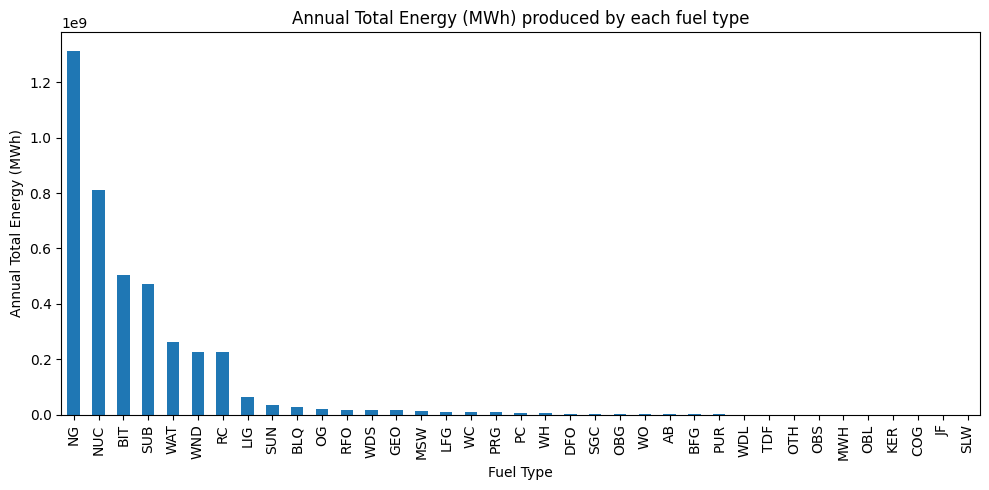

In [189]:
import matplotlib.pyplot as plt

fuel_totals = pd.DataFrame(data.groupby('PLPRMFL').PLNGENAN.sum())
fuel_totals = fuel_totals.sort_values(by="PLNGENAN", ascending=False)

# fuel_totals.head()
fuel_totals.plot(kind='bar', legend=False, figsize=(10,5))
plt.title("Annual Net Energy Generation (MWh) per fuel type")
plt.xlabel("Fuel Type")
plt.ylabel("Annual Net Energy Generation (MWh)")
plt.tight_layout()
plt.show()

## Answer 7e
Natural Gas plants have the greatest net energy generation annually.

## 8
**[6 points]** *Vectorization*. When we first learn to code and think about iterating over an array, we often use loops. If implemented correctly, that does the trick. In machine learning, we iterate over so much data that those loops can lead to significant slow downs if they are not computationally efficient. In Python, vectorizing code and relying on matrix operations with efficient tools like numpy is typically the faster approach. Of course, numpy relies on loops to complete the computation, but this is at a lower level of programming (typically in C), and therefore is much more efficient. This exercise will explore the benefits of vectorization. Since many machine learning techniques rely on matrix operations, it's helpful to begin thinking about implementing algorithms using vector forms.

Begin by creating an array of 1 million random numbers using the numpy `random.randn` module. Compute the sum of the squares of those random numbers first in a for loop, then using Numpy's `dot` module to perform an inner (dot) product. Time how long it takes to compute each and report the results and report the output. How many times faster is the vectorized code than the for loop approach? (Note - your results may vary from run to run).

Your output should use the `print()` function as follows (where the # symbols represent your answers, to a reasonable precision of 4-5 significant figures):

`Time [sec] (non-vectorized): ######`

`Time [sec] (vectorized):     ######`

`The vectorized code is ##### times faster than the nonvectorized code`

**ANSWER**

## 9
**[10 points]** This exercise will walk through some basic numerical programming and probabilistic thinking exercises, two skills which are frequently use in machine learning for answering questions from our data.
1. Synthesize $n=10^4$ normally distributed data points with mean $\mu=2$ and a standard deviation of $\sigma=1$. Call these observations from a random variable $X$, and call the vector of observations that you generate, $\textbf{x}$.
2. Calculate the mean and standard deviation of $\textbf{x}$ to validate (1) and provide the result to a precision of four significant figures.
3. Plot a histogram of the data in $\textbf{x}$ with 30 bins
4. What is the 90th percentile of $\textbf{x}$? The 90th percentile is the value below which 90% of observations can be found.
5. What is the 99th percentile of $\textbf{x}$?
6. Now synthesize $n=10^4$ normally distributed data points with mean $\mu=0$ and a standard deviation of $\sigma=3$. Call these observations from a random variable $Y$, and call the vector of observations that you generate, $\textbf{y}$.
7. Create a new figure and plot the histogram of the data in $\textbf{y}$ on the same axes with the histogram of $\textbf{x}$, so that both histograms can be seen and compared.
8. Using the observations from $\textbf{x}$ and $\textbf{y}$, estimate $E[XY]$

**ANSWER**

# Version Control via Git

## 10
**[4 points]** Git is efficient for collaboration, and expectation in industry, and one of the best ways to share results in academia. You can even use some Git repositories (e.g. Github) as hosts for website, such as with the [course website](https://kylebradbury.github.io/ids705/index.html). As a data scientist with experience in machine learning, Git is expected. We will interact with Git repositories (a.k.a. repos) throughout this course, and your project will require the use of git repos for collaboration.

Complete the [Atlassian Git tutorial](https://www.atlassian.com/git/tutorials/what-is-version-control), specifically the following listed sections. Try each concept that's presented. For this tutorial, instead of using BitBucket as your remote repository host, you may use your preferred platform such as [Github](https://github.com/) or [Duke's Gitlab](https://gitlab.oit.duke.edu/users/sign_in).
1. [What is version control](https://www.atlassian.com/git/tutorials/what-is-version-control)
2. [What is Git](https://www.atlassian.com/git/tutorials/what-is-git)
3. [Install Git](https://www.atlassian.com/git/tutorials/install-git)
4. [Setting up a repository](https://www.atlassian.com/git/tutorials/install-git)
5. [Saving changes](https://www.atlassian.com/git/tutorials/saving-changes)
6. [Inspecting a repository](https://www.atlassian.com/git/tutorials/inspecting-a-repository)
7. [Undoing changes](https://www.atlassian.com/git/tutorials/undoing-changes)
8. [Rewriting history](https://www.atlassian.com/git/tutorials/rewriting-history)
9. [Syncing](https://www.atlassian.com/git/tutorials/syncing)
10. [Making a pull request](https://www.atlassian.com/git/tutorials/making-a-pull-request)
11. [Using branches](https://www.atlassian.com/git/tutorials/using-branches)
12. [Comparing workflows](https://www.atlassian.com/git/tutorials/comparing-workflows)

I also have created two videos on the topic to help you understand some of these concepts: [Git basics](https://www.youtube.com/watch?v=fBCwfoBr2ng) and a [step-by-step tutorial](https://www.youtube.com/watch?v=nH7qJHx-h5s).

For your answer, affirm that you *either* completed the tutorials above OR have previous experience with ALL of the concepts above. Confirm this by typing your name below and selecting the situation that applies from the two options in brackets.

**ANSWER**

*I, [**your name here**], affirm that I have [**completed the above tutorial / I have previous experience that covers all the content in this tutorial**]*

# Exploratory Data Analysis
## 11
**[20 points]** Here you'll bring together some of the individual skills that you demonstrated above and create a Jupyter notebook based blog post on your exploratory data analysis. Your goal is to identify a question or problem and to work towards solving it or providing additional information or evidence (data) related to it through your data analysis. Below, we walk through a process to follow for your analysis. Additionally, you can find an [example of a well-done exploratory data analysis here from past years](https://github.com/kylebradbury/ids705/blob/master/assignments/Assignment_1_Q11_Example.ipynb).

1. Find a dataset that interests you and relates to a question or problem that you find intriguing.
2. Describe the dataset, the source of the data, and the reason the dataset was of interest. What question are you hoping to answer through exploring the dataset?
3. Check the data and see if they need to be cleaned: are there missing values? Are there clearly erroneous values? Do two tables need to be merged together? Clean the data so it can be visualized. If the data are clean, state how you know they are clean (what did you check?).
3. Plot the data, demonstrating interesting features that you discover. Are there any relationships between variables that were surprising or patterns that emerged? Please exercise creativity and curiosity in your plots. You should have at least a ~3 plots exploring the data in different ways.
4. What insights are you able to take away from exploring the data? Is there a reason why analyzing the dataset you chose is particularly interesting or important? Summarize this for a general audience (imagine your publishing a blog post online) - boil down your findings in a way that is accessible, but still accurate.

Here your analysis will evaluated based on:
1. Motivation: was the purpose of the choice of data clearly articulated? Why was the dataset chosen and what was the goal of the analysis?
2. Data cleaning: were any issues with the data investigated and, if found, were they resolved?
3. Quality of data exploration: were at least 4 unique plots (minimum) included and did those plots demonstrate interesting aspects of the data? Was there a clear purpose and takeaway from EACH plot?
4. Interpretation: Were the insights revealed through the analysis and their potential implications clearly explained? Was there an overall conclusion to the analysis?

**ANSWER**